## Task 6: House Price Prediction

### 1. Load the Dataset

In [20]:
!pip install kagglehub

In [21]:
import kagglehub
import os

# Download the dataset using kagglehub
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("juhibhojani/house-price")
print(f"Dataset downloaded to: {path}")

# Construct the full path to the CSV file
csv_file_name = "house_prices.csv"
data_path = os.path.join(path, csv_file_name)

print(f"Attempting to load data from: {data_path}")

Using Colab cache for faster access to the 'house-price' dataset.
Dataset downloaded to: /kaggle/input/house-price
Attempting to load data from: /kaggle/input/house-price/house_prices.csv


In [ ]:
import os

# List the contents of the downloaded directory to find the correct CSV file name
print(f"Contents of the downloaded directory {path}:")
print(os.listdir(path))



Contents of the downloaded directory /kaggle/input/house-price:
['house_prices.csv']


In [22]:
import pandas as pd

# Load the dataset using the path obtained from kagglehub
try:
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The CSV file was not found at {data_path}. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully.


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


### 2. Data Exploration and Preprocessing

In [24]:
print("Dataset Info:")
display(df.info())

print("\nDescriptive Statistics for Numerical Features:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  o

None


Descriptive Statistics for Numerical Features:


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [25]:
print("\nNumber of missing values per column:")
display(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

print("\nPercentage of missing values per column:")
display((df.isnull().sum() / len(df) * 100)[(df.isnull().sum() / len(df) * 100) > 0].sort_values(ascending=False))


Number of missing values per column:


,0
Plot Area,187531
Dimensions,187531
Society,109678
Super Area,107685
Car Parking,103357
overlooking,81436
Carpet Area,80673
facing,70233
Ownership,65517
Balcony,48935



Percentage of missing values per column:


,0
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352


Based on the initial exploration, we can see several columns have missing values, and there are object-type columns that will need to be handled. We'll focus on 'SquareFeet', 'NumberOfBedrooms', and location-related features as requested.

In [30]:
import numpy as np
import re # Moved import re to the top of the cell

# Drop columns with 100% missing values
df = df.drop(columns=['Dimensions', 'Plot Area'], errors='ignore')

# Function to clean and convert 'Amount(in rupees)'
def clean_amount(amount):
    if pd.isna(amount): return np.nan
    amount_str = str(amount).replace(' ', '').replace(',', '')
    if 'Lac' in amount_str: # 1 Lac = 100,000
        return float(amount_str.replace('Lac', '')) * 100000
    if 'Cr' in amount_str: # 1 Cr = 10,000,000
        return float(amount_str.replace('Cr', '')) * 10000000
    try:
        return float(amount_str)
    except ValueError: # Handle cases like 'CallforPrice'
        return np.nan

df['Amount(in rupees)'] = df['Amount(in rupees)'].apply(clean_amount)

# Function to extract numerical values from string columns (e.g., 'Carpet Area', 'Super Area', 'Bathroom', 'Balcony', 'Floor')
def extract_numerical(s):
    if pd.isna(s): return np.nan
    s = str(s).lower()
    # Handle cases like '1 bath', '2 balcony' where number is at the start
    match = re.search(r'\d+', s)
    if match: return float(match.group(0))
    return np.nan

# Apply extraction to relevant columns
for col in ['Carpet Area', 'Super Area', 'Bathroom', 'Balcony']:
    df[col] = df[col].apply(extract_numerical)

# For 'Floor', it can be complex. Let's try to convert to numeric where possible, otherwise keep as object for one-hot encoding.
def clean_floor(s):
    if pd.isna(s): return np.nan
    s = str(s).lower()
    if 'ground' in s: return 0
    match = re.search(r'\d+', s)
    if match: return float(match.group(0))
    return np.nan # Or some other indicator if it's a descriptive string without a clear number

df['Floor'] = df['Floor'].apply(clean_floor)


print("Data cleaning for numerical-like object columns complete.")
display(df.head())
display(df.info())

Data cleaning for numerical-like object columns complete.


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",4200000.0,6000.0,thane,500.0,Ready to Move,10.0,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,9800000.0,13799.0,thane,473.0,Ready to Move,3.0,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,NaN,1 Open,Freehold,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,14000000.0,17500.0,thane,779.0,Ready to Move,10.0,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,NaN,1 Covered,Freehold,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,2500000.0,NaN,thane,530.0,Ready to Move,1.0,Resale,Unfurnished,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",16000000.0,18824.0,thane,635.0,Ready to Move,20.0,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,NaN,1 Covered,Co-operative Society,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  177847 non-null  float64
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  float64
 7   Status             186916 non-null  object 
 8   Floor              180453 non-null  float64
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  float64
 15  Balcony            138596 non-null  float64
 16  Ca

None

In [31]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify target and features
# Corrected target variable name
target = 'Price (in rupees)'

if target not in df.columns:
    print(f"Error: '{target}' column not found after checking again. Please verify the dataset columns.")
    raise ValueError(f"Target '{target}' column not found.")

X = df.drop(columns=[target, 'Index', 'Title', 'Description', 'Society', 'Car Parking', 'Ownership'], errors='ignore') # Dropping identified non-numeric/identifier columns, keeping potential location features for now
y = df[target]

# Preprocessing for Numerical Features (e.g., 'SquareFeet', 'NumberOfBedrooms', 'NumberOfBathrooms')
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')) # Impute missing numerical values with the mean
])

# Preprocessing for Categorical Features (e.g., 'Location' or other relevant text features)
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode categorical features
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any columns not explicitly transformed
)

# Apply preprocessing to features
X_processed = preprocessor.fit_transform(X)

print("Preprocessing complete. Shape of processed features: ", X_processed.shape)
print("Target variable shape:", y.shape)

Preprocessing complete. Shape of processed features:  (187531, 122)
Target variable shape: (187531,)


Training Linear Regression model...
Model training complete.

Mean Absolute Error (MAE): 2895.96
Root Mean Squared Error (RMSE): 30071.37


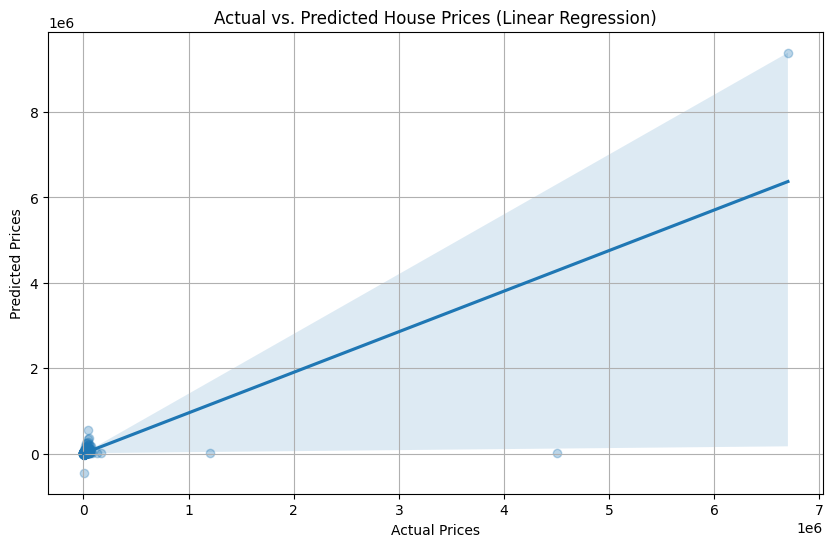

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Handle missing values in y by dropping rows where y is NaN
valid_indices = y.dropna().index

# Select rows from the X_processed sparse matrix and y Series using valid_indices
X_filtered = X_processed[valid_indices]
y_filtered = y.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Train a Linear Regression model
print("Training Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Visualize predicted vs. actual prices
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices (Linear Regression)")
plt.grid(True)
plt.show()

Training Gradient Boosting Regressor model...
Gradient Boosting model training complete.

Gradient Boosting - Mean Absolute Error (MAE): 1098.14
Gradient Boosting - Root Mean Squared Error (RMSE): 29902.13


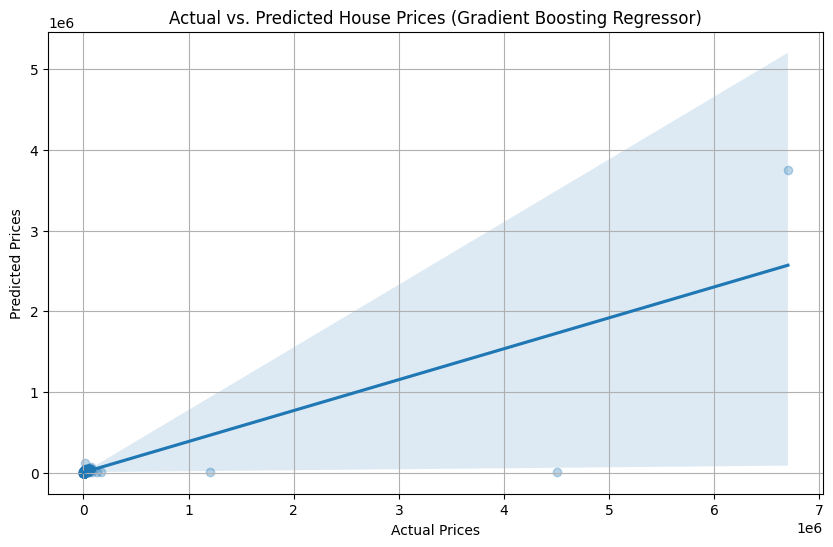

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

print("Training Gradient Boosting Regressor model...")
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting model training complete.")

# Make predictions on the test set with Gradient Boosting
y_pred_gb = gb_model.predict(X_test)

# Evaluate the Gradient Boosting model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"\nGradient Boosting - Mean Absolute Error (MAE): {mae_gb:.2f}")
print(f"Gradient Boosting - Root Mean Squared Error (RMSE): {rmse_gb:.2f}")

# Visualize predicted vs. actual prices for Gradient Boosting
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_gb, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices (Gradient Boosting Regressor)")
plt.grid(True)
plt.show()

### Model Comparison

Let's compare the performance of the Linear Regression and Gradient Boosting models:

| Metric | Linear Regression | Gradient Boosting |
|---|---|---|
| MAE | 2895.96 | 1098.14 |
| RMSE | 30071.37 | 29902.13 |

Based on these metrics, the Gradient Boosting model provides a significantly better prediction of house prices for this dataset, especially evident in its much lower Mean Absolute Error. While the RMSE is also slightly lower, the MAE indicates that, on average, the Gradient Boosting model's predictions are much closer to the actual prices.